In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
from fiona.crs import from_string
from matplotlib import pyplot as plt
import matplotlib as mpl
import os
from tqdm import tqdm

# PurpleAir

## Prepare Data

In [3]:
dir_path = "./data/processed/purpleair/"
X_purple_all = []
Y_purple_all = []

for file_name in os.listdir(dir_path):
    if not file_name.endswith(".csv"):
        continue

    df = pd.read_csv(dir_path + file_name)
    X_temp = df[["longitude", "latitude"]].values
    Y_temp = df["pm25"].values
    X_purple_all.append(X_temp)
    Y_purple_all.append(Y_temp)
X_purple_all= np.array(X_purple_all).transpose(1, 0, 2)
Y_purple_all = np.array(Y_purple_all).transpose(1, 0)

# X: (time steps, num of sensors, feature dimension)
# Y: (time steps, num of sensors)
print(X_purple_all.shape)
print(Y_purple_all.shape)

(744, 46, 2)
(744, 46)


In [18]:
# train test split
def train_test_split(X, Y, train_ratio=0.8, seed=42):
    """
    param X: (time steps, num of sensors, 2)
    param Y: (time steps, num of sensors)
    param train_ratio: ratio of training data
    param seed: random seed
    """
    # set random seed
    np.random.seed(seed)

    # get train and test index
    n_steps, n_sensors, n_features = X.shape
    n_train = int(n_sensors * train_ratio)
    permutation = np.random.permutation(n_sensors)
    train_idx = permutation[:n_train]
    test_idx = permutation[n_train:]

    # split train and test
    X_train = X[:, train_idx, :]
    Y_train = Y[:, train_idx]
    X_test = X[:, test_idx, :]
    Y_test = Y[:, test_idx]

    return X_train, Y_train, X_test, Y_test

X_purple_train, Y_purple_train, X_purple_test, Y_purple_test = train_test_split(X_purple_all, Y_purple_all)
print(X_purple_train.shape)
print(Y_purple_train.shape)
print(X_purple_test.shape)
print(Y_purple_test.shape)

(744, 36, 2)
(744, 36)
(744, 10, 2)
(744, 10)


## Inverse Distance Weighting

In [19]:
class IDW:
    def __init__(self, X_train, Y_train):
        """
        Inverse Distance Weighting

        param X_train: numpy array of shape (n_train, 2); 2 stands for 2-D location
        param Y_train: numpy array of shape (n_train, )
        """
        self.X_train = X_train
        self.Y_train = Y_train

    def predict(self, X_test):
        """
        param X_test: numpy array of shape (n_test, 2)
        """
        # get distance matrix of shape (n_test, n_train)
        diff = X_test[:, np.newaxis, :] - self.X_train[np.newaxis, :, :]
        distm = np.sum(diff ** 2, axis=-1)
        distm = distm + 1e-16

        # get inverse distance matrix of shape (n_test, n_train)
        inv_distm = 1 / distm

        # get prediction of shape (n_test, )
        pred = np.sum(inv_distm * self.Y_train[np.newaxis, :], axis=-1) / np.sum(inv_distm, axis=-1)

        return pred

In [9]:
# make prediction
MAEs = []
for t in range(len(X_purple_train)):
    model = IDW(X_purple_train[t], Y_purple_train[t])
    pred = model.predict(X_purple_test[t])
    MAE = np.mean(np.abs(pred - Y_purple_test[t]))
    MAEs.append(MAE)
print(np.mean(MAEs))

2.4359253301880988


In [10]:
# Do it for 10 different seeds
MAEs = []
for seed in range(10):
    X_purple_train, Y_purple_train, X_purple_test, Y_purple_test = train_test_split(X_purple_all, Y_purple_all, seed=seed)
    for t in range(len(X_purple_train)):
        model = IDW(X_purple_train[t], Y_purple_train[t])
        pred = model.predict(X_purple_test[t])
        MAE = np.mean(np.abs(pred - Y_purple_test[t]))
        MAEs.append(MAE)
print(np.mean(MAEs))
print(np.std(MAEs))

2.1264221595234876
1.2966347713233708


# AQview and AirNow

## Prepare Data

In [4]:
dir_path = "./data/processed/aqan/"
X_aqan_all = []
Y_aqan_all = []

for file_name in os.listdir(dir_path):
    if not file_name.endswith(".csv"):
        continue

    df = pd.read_csv(dir_path + file_name)
    X_temp = df[["longitude", "latitude"]].values
    Y_temp = df["pm25"].values
    X_aqan_all.append(X_temp)
    Y_aqan_all.append(Y_temp)
X_aqan_all = np.array(X_aqan_all).transpose(1, 0, 2)
Y_aqan_all = np.array(Y_aqan_all).transpose(1, 0)

# X: (time steps, num of sensors, feature dimension)
# Y: (time steps, num of sensors)
print(X_aqan_all.shape)
print(Y_aqan_all.shape)

(744, 5, 2)
(744, 5)


In [24]:
# Leave-one-out split
def leave_one_out_split(X, Y, leave_idx=0):
    """
    param X: (time steps, num of sensors, 2)
    param Y: (time steps, num of sensors)
    param leave_idx: index of the sensor to leave out
    """
    # get train and test index
    n_steps, n_sensors, n_features = X.shape
    if leave_idx >= n_sensors:
        raise ValueError("leave_idx must be smaller than n_sensors")
    train_idx = np.arange(n_sensors) != leave_idx
    test_idx = np.arange(n_sensors) == leave_idx

    # split train and test
    X_train = X[:, train_idx, :]
    Y_train = Y[:, train_idx]
    X_test = X[:, test_idx, :]
    Y_test = Y[:, test_idx]

    return X_train, Y_train, X_test, Y_test

X_aqan_train, Y_aqan_train, X_aqan_test, Y_aqan_test = leave_one_out_split(X_aqan_all, Y_aqan_all)
print(X_aqan_train.shape)
print(Y_aqan_train.shape)
print(X_aqan_test.shape)
print(Y_aqan_test.shape)

(744, 4, 2)
(744, 4)
(744, 1, 2)
(744, 1)


## Inverse Distance Weighting

In [13]:
# make prediction
MAEs = []
for t in range(len(X_aqan_train)):
    model = IDW(X_aqan_train[t], Y_aqan_train[t])
    pred = model.predict(X_aqan_test[t])
    MAE = np.mean(np.abs(pred - Y_aqan_test[t]))
    MAEs.append(MAE)
print(np.mean(MAEs))
print(np.std(MAEs))

6.563056596099528
6.705785185809467


In [14]:
# Leave-one-out cross validation
MAEs = []
for leave_idx in range(X_aqan_all.shape[1]):
    X_aqan_train, Y_aqan_train, X_aqan_test, Y_aqan_test = leave_one_out_split(X_aqan_all, Y_aqan_all, leave_idx)
    for t in range(len(X_aqan_train)):
        model = IDW(X_aqan_train[t], Y_aqan_train[t])
        pred = model.predict(X_aqan_test[t])
        MAE = np.mean(np.abs(pred - Y_aqan_test[t]))
        MAEs.append(MAE)
print(np.mean(MAEs))

6.427262745571058


# AQAN as ground truth for PurpleAIr

## Inverse Distance Weighting

In [15]:
X_train = X_purple_all
Y_train = Y_purple_all
X_test = X_aqan_all
Y_test = Y_aqan_all
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)


(744, 46, 2)
(744, 46)
(744, 5, 2)
(744, 5)


In [16]:
# make prediction
MAEs = []
for t in range(len(X_train)):
    model = IDW(X_train[t], Y_train[t])
    pred = model.predict(X_test[t])
    MAE = np.mean(np.abs(pred - Y_test[t]))
    MAEs.append(MAE)
print(np.mean(MAEs))
print(np.std(MAEs))

6.772147306578757
3.8097155251074954


# Get interpolation Map

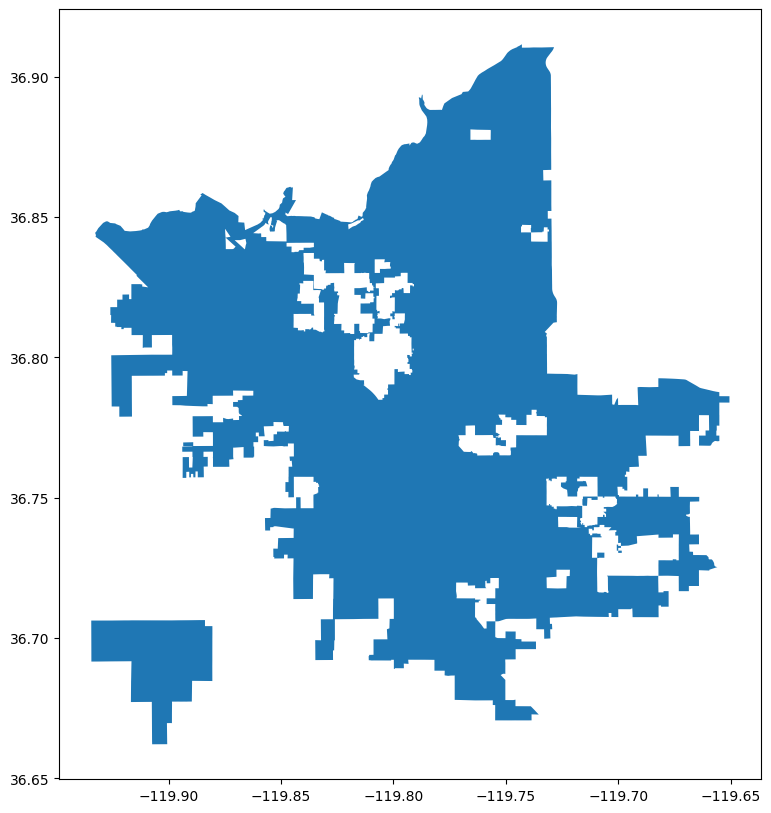

In [6]:
# Load Fresno Map
ca_map = gpd.read_file("../Map_Data/ca-places-boundaries/CA_Places_TIGER2016.shp")
crs = from_string("+proj=longlat +datum=WGS84 +no_defs")
ca_map = ca_map.to_crs(crs)
fresno_map = ca_map[ca_map["NAME"].isin(["Fresno"])]

# visualize
fig_fresno, ax_fresno = plt.subplots(figsize=(10, 10))
fresno_map.plot(ax=ax_fresno)
plt.show()

In [18]:
color_list = [(0, "green"), (12 / 250, "yellow"), (35 / 250, "orange"), (55 / 250, "red"), (150 / 250, "purple"), (1, "maroon")]
custom_cmap = mpl.colors.LinearSegmentedColormap.from_list("custom_cmap", color_list)

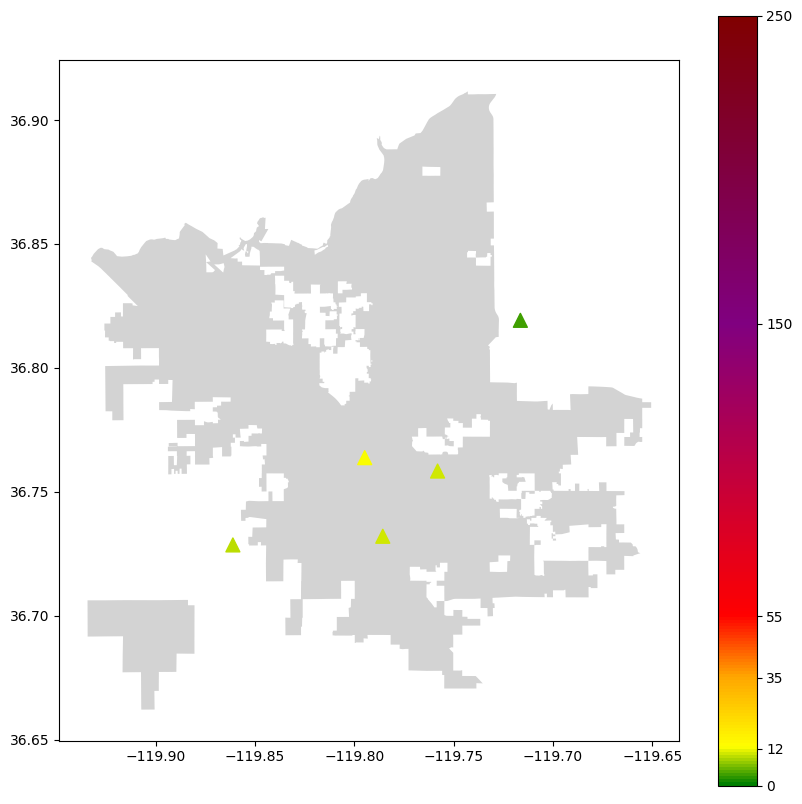

In [19]:
coords_aqan = X_aqan_all[0].transpose(1, 0)
fig_fresno, ax_fresno = plt.subplots(figsize=(10, 10))
fresno_map.plot(ax=ax_fresno, color="lightgrey")
sc = ax_fresno.scatter(coords_aqan[0], coords_aqan[1],
                       c=Y_aqan_all[-1], cmap=custom_cmap,
                       marker="^", s=100,
                       vmin=0, vmax=250)
plt.colorbar(sc, ax=ax_fresno, ticks=[0, 12, 35, 55, 150, 250])
plt.show()

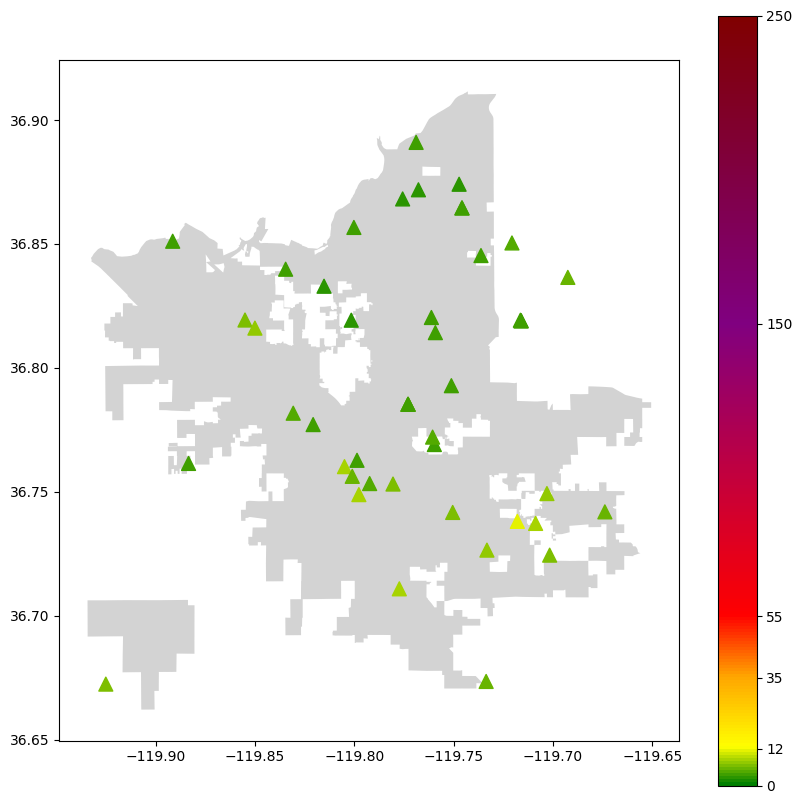

In [20]:
coords = X_purple_all[0].transpose(1, 0)
fig_fresno, ax_fresno = plt.subplots(figsize=(10, 10))
fresno_map.plot(ax=ax_fresno, color="lightgrey")
sc = ax_fresno.scatter(coords[0], coords[1],
                       c=Y_purple_all[-1], cmap=custom_cmap,
                       marker="^", s=100,
                       vmin=0, vmax=250)
plt.colorbar(sc, ax=ax_fresno, ticks=[0, 12, 35, 55, 150, 250])
plt.show()

# Estimate HeatMap

In [21]:
t = 564
estimator_aqan = IDW(X_aqan_all[t], Y_aqan_all[t])
map_bound = (-119.95, 36.65, -119.65, 36.95)

In [22]:
# create meshgrid
x = np.linspace(map_bound[0], map_bound[2], 50 * 2 + 1)[1::2]
y = np.linspace(map_bound[1], map_bound[3], 50 * 2 + 1)[1::2]
xx, yy = np.meshgrid(x, y)

In [23]:
# iterate over meshgrid
pred = []
for i in range(xx.shape[0]):
    for j in range(xx.shape[1]):
        pred.append(estimator_aqan.predict(np.array([[xx[i, j], yy[i, j]]])))

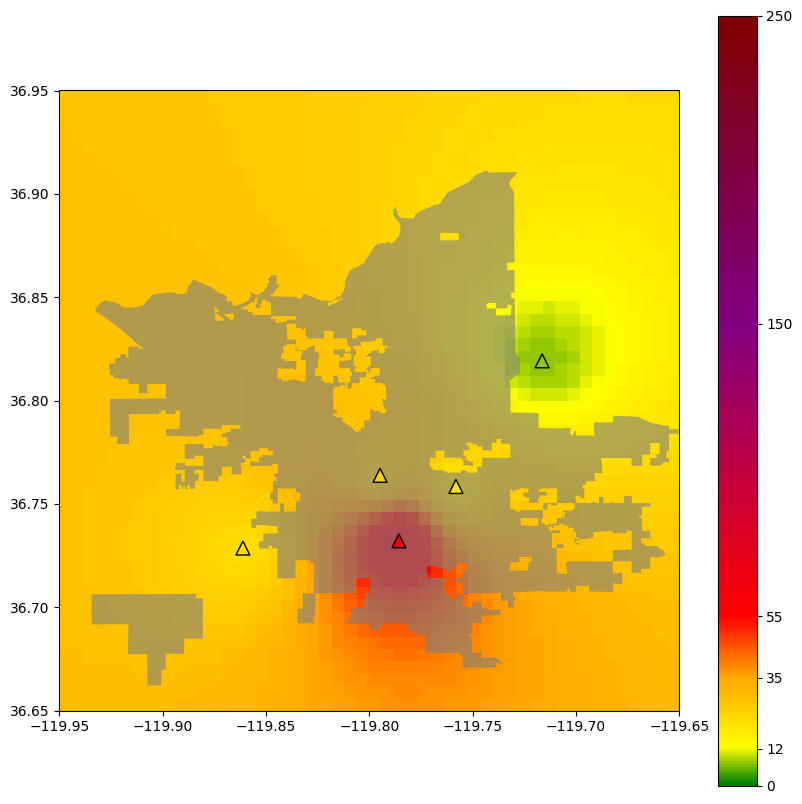

In [24]:
# visualize
pred = np.array(pred).reshape(xx.shape)
fig_fresno, ax_fresno = plt.subplots(figsize=(10, 10))
fresno_map.plot(ax=ax_fresno, alpha=0.6, color="grey")
sc = plt.imshow(pred, extent=(map_bound[0], map_bound[2], map_bound[1], map_bound[3]),
           origin="lower", alpha=1,
           cmap=custom_cmap, vmin=0, vmax=250)
ax_fresno.scatter(coords_aqan[0], coords_aqan[1],
                c=Y_aqan_all[t], cmap=custom_cmap, edgecolors="black",
                marker="^", s=100,
                vmin=0, vmax=250)
plt.colorbar(sc, ax=ax_fresno, ticks=[0, 12, 35, 55, 150, 250])
plt.show()

## Generate Video

In [41]:
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
import cv2

def month_n2s(n):
    if n == 1:
        return "Jan"
    elif n == 2:
        return "Feb"
    elif n == 3:
        return "Mar"
    elif n == 4:
        return "Apr"
    elif n == 5:
        return "May"
    elif n == 6:
        return "Jun"
    elif n == 7:
        return "Jul"
    elif n == 8:
        return "Aug"
    elif n == 9:
        return "Sep"
    elif n == 10:
        return "Oct"
    elif n == 11:
        return "Nov"
    elif n == 12:
        return "Dec"

In [26]:
def fig_to_rgb(fig):
    canvas = FigureCanvas(fig)
    canvas.draw()
    buf = canvas.buffer_rgba()
    return np.array(buf)[:, :, :3]


# create meshgrid
x = np.linspace(map_bound[0], map_bound[2], 50 * 2 + 1)[1::2]
y = np.linspace(map_bound[1], map_bound[3], 50 * 2 + 1)[1::2]
xx, yy = np.meshgrid(x, y)


In [ ]:
fourcc = cv2.VideoWriter_fourcc('M', 'J', 'P', 'G')
out = cv2.VideoWriter("map_change_aqan.avi", fourcc, 10.0, (1000, 1000))


for t in range(len(X_aqan_all)):
    # get estimator
    estimator_aqan = IDW(X_aqan_all[t], Y_aqan_all[t])

    # get prediction for each grid
    pred = []
    for i in range(xx.shape[0]):
        for j in range(xx.shape[1]):
            pred.append(estimator_aqan.predict(np.array([[xx[i, j], yy[i, j]]])))
    pred = np.array(pred).reshape(xx.shape)

    # visualize
    fig_fresno, ax_fresno = plt.subplots(figsize=(10, 10))
    fresno_map.plot(ax=ax_fresno, alpha=0.6, color="grey")
    sc = plt.imshow(pred, extent=(map_bound[0], map_bound[2], map_bound[1], map_bound[3]),
            origin="lower", alpha=1,
            cmap=custom_cmap, vmin=0, vmax=250)
    ax_fresno.scatter(coords_aqan[0], coords_aqan[1],
                    c=Y_aqan_all[t], cmap=custom_cmap, edgecolors="black",
                    marker="^", s=100,
                    vmin=0, vmax=250)
    plt.colorbar(sc, ax=ax_fresno, ticks=[0, 12, 35, 55, 150, 250])
    image = fig_to_rgb(fig_fresno)[:, :, ::-1]
    plt.close(fig_fresno)

    # write to video
    out.write(image)
    print(f"Frame {t + 1}")

out.release()

In [48]:
fourcc = cv2.VideoWriter_fourcc('M', 'J', 'P', 'G')
out = cv2.VideoWriter("map_change_purple.avi", fourcc, 10.0, (1000, 1000))

# all purple air sensors' location
coords_purple = X_purple_all[0].transpose(1, 0)

for t in range(len(X_aqan_all)):
    # get estimator
    estimator_purple = IDW(X_purple_all[t], Y_purple_all[t])

    # get prediction for each grid
    pred = []
    for i in range(xx.shape[0]):
        for j in range(xx.shape[1]):
            pred.append(estimator_purple.predict(np.array([[xx[i, j], yy[i, j]]])))
    pred = np.array(pred).reshape(xx.shape)

    # visualize
    fig_fresno, ax_fresno = plt.subplots(figsize=(10, 10))
    fresno_map.plot(ax=ax_fresno, alpha=0.6, color="grey")
    sc = plt.imshow(pred, extent=(map_bound[0], map_bound[2], map_bound[1], map_bound[3]),
            origin="lower", alpha=1,
            cmap=custom_cmap, vmin=0, vmax=250)
    ax_fresno.scatter(coords_purple[0], coords_purple[1],
                    c=Y_purple_all[t], cmap=custom_cmap, edgecolors="black",
                    marker="^", s=100,
                    vmin=0, vmax=250)
    
    # set title
    hour = str(df.loc[t, "hour"])
    hour = hour if len(hour) == 2 else "0" + hour
    day = df.loc[t, "day"]
    month = month_n2s(df.loc[t, "month"])
    year = df.loc[t, "year"]
    ax_fresno.set_title(f"{hour}:00 {month} {day} {year}", fontsize=20)
    
    # create colorbar
    cbar = plt.colorbar(sc, ax=ax_fresno, ticks=[0, 12, 35, 55, 150, 250],
                        label="PM2.5 (ug / m^3)")
    cbar.ax.set_ylabel("PM2.5 (ug / m^3)", rotation=270, labelpad=20,
                        fontsize=20)

    # write image to video
    image = fig_to_rgb(fig_fresno)[:, :, ::-1]
    plt.close(fig_fresno)
    out.write(image)
    # print(f"Frame {t + 1}")
    # if t == 10:
    #     print("finished")
    #     break

print("Finised")
out.release()

Finised


numpy.int64

In [ ]:
fourcc = cv2.VideoWriter_fourcc('M', 'J', 'P', 'G')
out = cv2.VideoWriter("map_change_aqan_cate.avi", fourcc, 10.0, (1000, 1000))


for t in range(len(X_aqan_all)):
    # get estimator
    estimator_aqan = IDW(X_aqan_all[t], Y_aqan_all[t])

    # get prediction for each grid
    pred = []
    for i in range(xx.shape[0]):
        for j in range(xx.shape[1]):
            pred.append(estimator_aqan.predict(np.array([[xx[i, j], yy[i, j]]])))
    pred = np.array(pred).reshape(xx.shape)

    # categorize
    def categorize(x):
        x[x < 12] = 0
        x[(x >= 12) & (x < 35)] = 12
        x[(x >= 35) & (x < 55)] = 35
        x[(x >= 55) & (x < 150)] = 55
        x[(x >= 150)] = 150
        return x
    pred = categorize(pred)

    # visualize
    fig_fresno, ax_fresno = plt.subplots(figsize=(10, 10))
    fresno_map.plot(ax=ax_fresno, alpha=0.6, color="grey")
    sc = plt.imshow(pred, extent=(map_bound[0], map_bound[2], map_bound[1], map_bound[3]),
            origin="lower", alpha=1,
            cmap=custom_cmap, vmin=0, vmax=250)
    ax_fresno.scatter(coords_aqan[0], coords_aqan[1],
                    c=Y_aqan_all[t], cmap=custom_cmap, edgecolors="black",
                    marker="^", s=100,
                    vmin=0, vmax=250)
    plt.colorbar(sc, ax=ax_fresno, ticks=[0, 12, 35, 55, 150, 250])
    image = fig_to_rgb(fig_fresno)[:, :, ::-1]
    plt.close(fig_fresno)

    # write to video
    out.write(image)
    print(f"Frame {t + 1}")

out.release()

In [ ]:
fourcc = cv2.VideoWriter_fourcc('M', 'J', 'P', 'G')
out = cv2.VideoWriter("map_change_purple_cate.avi", fourcc, 10.0, (1000, 1000))

coords_purple = X_purple_all[0].transpose(1, 0)

for t in range(len(X_aqan_all)):
    # get estimator
    estimator_purple = IDW(X_purple_all[t], Y_purple_all[t])

    # get prediction for each grid
    pred = []
    for i in range(xx.shape[0]):
        for j in range(xx.shape[1]):
            pred.append(estimator_purple.predict(np.array([[xx[i, j], yy[i, j]]])))
    pred = np.array(pred).reshape(xx.shape)

    # categorize
    def categorize(x):
        x[x < 12] = 0
        x[(x >= 12) & (x < 35)] = 12
        x[(x >= 35) & (x < 55)] = 35
        x[(x >= 55) & (x < 150)] = 55
        x[(x >= 150)] = 150
        return x
    pred = categorize(pred)

    # visualize
    fig_fresno, ax_fresno = plt.subplots(figsize=(10, 10))
    fresno_map.plot(ax=ax_fresno, alpha=0.6, color="grey")
    sc = plt.imshow(pred, extent=(map_bound[0], map_bound[2], map_bound[1], map_bound[3]),
            origin="lower", alpha=1,
            cmap=custom_cmap, vmin=0, vmax=250)
    ax_fresno.scatter(coords_purple[0], coords_purple[1],
                    c=Y_purple_all[t], cmap=custom_cmap, edgecolors="black",
                    marker="^", s=100,
                    vmin=0, vmax=250)
    plt.colorbar(sc, ax=ax_fresno, ticks=[0, 12, 35, 55, 150, 250])
    
    image = fig_to_rgb(fig_fresno)[:, :, ::-1]
    plt.close(fig_fresno)


    out.write(image)
    print(f"Frame {t + 1}")
    # if t == 100:
    #     break

out.release()

## AQAN PurpleAir Compare

In [71]:
fourcc = cv2.VideoWriter_fourcc('M', 'J', 'P', 'G')
out = cv2.VideoWriter("aqan_purple_compare.avi", fourcc, 5.0, (2000, 1000))

# all sensors' location
coords_aqan = X_aqan_all[0].transpose(1, 0)
coords_purple = X_purple_all[0].transpose(1, 0)

for t in tqdm(range(len(X_aqan_all))):
    # get estimator
    estimator_aqan = IDW(X_aqan_all[t], Y_aqan_all[t])
    estimator_purple = IDW(X_purple_all[t], Y_purple_all[t])

    # get prediction for each grid
    pred_aqan = []
    for i in range(xx.shape[0]):
        for j in range(xx.shape[1]):
            pred_aqan.append(estimator_aqan.predict(np.array([[xx[i, j], yy[i, j]]])))
    pred_aqan = np.array(pred_aqan).reshape(xx.shape)
    pred_purple = []
    for i in range(xx.shape[0]):
        for j in range(xx.shape[1]):
            pred_purple.append(estimator_purple.predict(np.array([[xx[i, j], yy[i, j]]])))
    pred_purple = np.array(pred_purple).reshape(xx.shape)

    # visualize
    fig_aqan, ax_aqan = plt.subplots(figsize=(10, 10))
    fresno_map.plot(ax=ax_aqan, alpha=0.6, color="grey")
    sc = plt.imshow(pred_aqan, extent=(map_bound[0], map_bound[2], map_bound[1], map_bound[3]),
            origin="lower", alpha=1,
            cmap=custom_cmap, vmin=0, vmax=250)
    ax_aqan.scatter(coords_aqan[0], coords_aqan[1],
                    c=Y_aqan_all[t], cmap=custom_cmap, edgecolors="black",
                    marker="^", s=100,
                    vmin=0, vmax=250)
    
    fig_purple, ax_purple = plt.subplots(figsize=(10, 10))
    fresno_map.plot(ax=ax_purple, alpha=0.6, color="grey")
    sc = plt.imshow(pred_purple, extent=(map_bound[0], map_bound[2], map_bound[1], map_bound[3]),
            origin="lower", alpha=1,
            cmap=custom_cmap, vmin=0, vmax=250)
    ax_purple.scatter(coords_purple[0], coords_purple[1],
                    c=Y_purple_all[t], cmap=custom_cmap, edgecolors="black",
                    marker="s", s=100,
                    vmin=0, vmax=250)

    
    # set title
    hour = str(df.loc[t, "hour"])
    hour = hour if len(hour) == 2 else "0" + hour
    day = df.loc[t, "day"]
    month = month_n2s(df.loc[t, "month"])
    year = df.loc[t, "year"]
    ax_aqan.set_title(f"{hour}:00 {month} {day} {year}", fontsize=20)
    ax_purple.set_title(f"{hour}:00 {month} {day} {year}", fontsize=20)
    
    # create colorbar
    cbar = plt.colorbar(sc, ax=ax_aqan, ticks=[0, 12, 35, 55, 150, 250],
                        label="PM2.5 (ug / m^3)")
    cbar.ax.set_ylabel("PM2.5 (ug / m^3)", rotation=270, labelpad=20,
                        fontsize=20)
    cbar = plt.colorbar(sc, ax=ax_purple, ticks=[0, 12, 35, 55, 150, 250],
                        label="PM2.5 (ug / m^3)")
    cbar.ax.set_ylabel("PM2.5 (ug / m^3)", rotation=270, labelpad=20,
                        fontsize=20)

    # write image to video
    image_aqan = fig_to_rgb(fig_aqan)[:, :, ::-1]
    image_purple = fig_to_rgb(fig_purple)[:, :, ::-1]
    image = np.concatenate((image_aqan, image_purple), axis=1)
    plt.close(fig_aqan)
    plt.close(fig_purple)
    out.write(image)
    # print(f"Frame {t + 1}")
#     if t == 10:
#         break
    

print("Finised")
out.release()

100%|██████████| 744/744 [02:23<00:00,  5.18it/s]

Finised


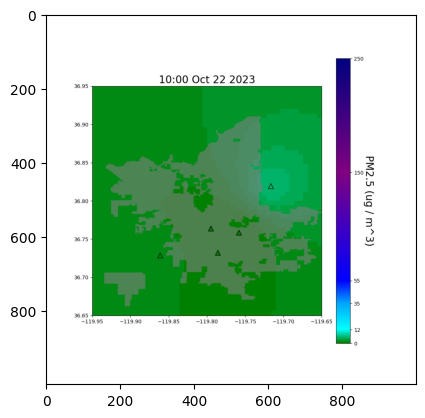

In [69]:
plt.imshow(image_aqan)

In [62]:
df

,year,month,day,hour,minute,pm25,longitude,latitude
0,2023,10,22,0,0,6.0,-119.8612,36.7286
1,2023,10,22,1,0,0.0,-119.8612,36.7286
2,2023,10,22,2,0,0.0,-119.8612,36.7286
3,2023,10,22,3,0,0.7,-119.8612,36.7286
4,2023,10,22,4,0,0.6,-119.8612,36.7286
...,...,...,...,...,...,...,...,...
739,2023,11,21,19,0,19.2,-119.8612,36.7286
740,2023,11,21,20,0,10.5,-119.8612,36.7286
741,2023,11,21,21,0,10.3,-119.8612,36.7286
742,2023,11,21,22,0,6.9,-119.8612,36.7286


# Controlled PurpleAir Data

## Prepare Data

In [ ]:
dir_path = "./data/precessed/purpleair/"
X_purple_controlled = []
Y_purple_controlled = []

for file_name in os.listdir(dir_path):
    if not file_name.endswith(".csv"):
        continue

    df = pd.read_csv(dir_path + file_name)
    X_temp = df[["longitude", "latitude"]].values
    Y_temp = df["pm25"].values
    X_purple_controlled.append(X_temp)
    Y_purple_controlled.append(Y_temp)

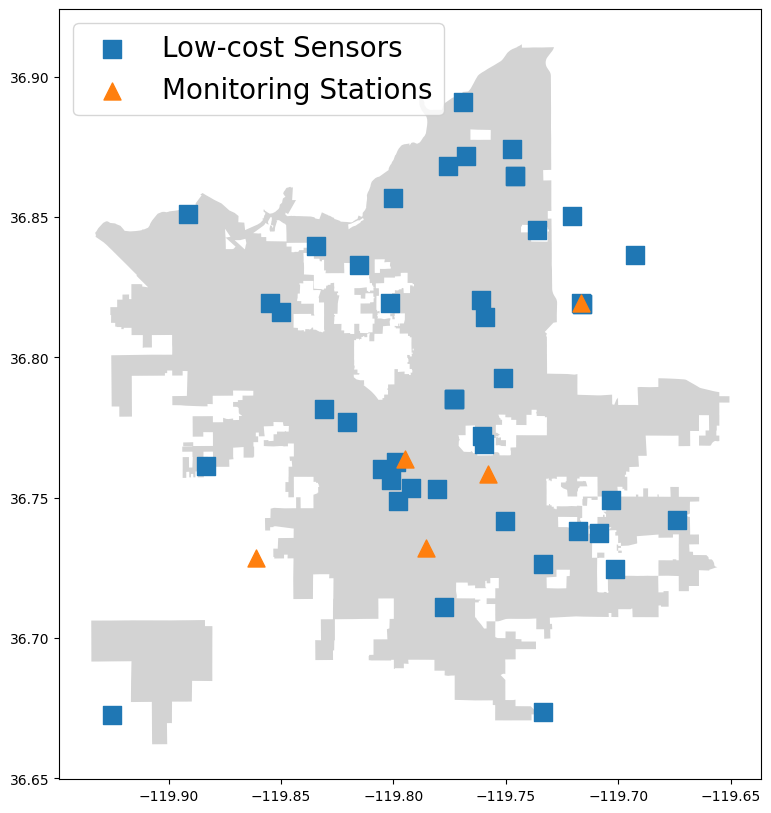

In [41]:
coords_purple = X_purple_all[0].transpose(1, 0)
coords_aqan = X_aqan_all[0].transpose(1, 0)

fig, ax = plt.subplots(figsize=(10, 10))
fresno_map.plot(ax=ax, color="lightgrey")
ax.scatter(coords_purple[0], coords_purple[1], marker="s", s=150, alpha=1,
           label="Low-cost Sensors")

purple_controlled_index = [0, 2, 12, 17, 31, 42, 4, 35, 26, 18, 21, 45, 43, 30]
# ax.scatter(coords_purple[0][purple_controlled_index], coords_purple[1][purple_controlled_index],
#            marker="s", s=150, color="blue", label="Low-cost Sensors")
ax.scatter(coords_aqan[0], coords_aqan[1], marker="^", s=150,
           label="Monitoring Stations")
plt.legend(fontsize=20)
plt.show()

In [16]:
X_purple_air_controlled = X_purple_all[:, purple_controlled_index, :]
Y_purple_air_controlled = Y_purple_all[:, purple_controlled_index]
print(X_purple_air_controlled.shape)
print(Y_purple_air_controlled.shape)

(744, 14, 2)
(744, 14)


# Interpolation with PurpleAir

In [29]:
# Test for different seeds
MAEs = []
for seed in range(500):
    np.random.seed(seed)
    rnd_index = np.random.permutation(14)[:5]
    X_random = X_purple_all[:, rnd_index, :]
    Y_random = Y_purple_all[:, rnd_index]
    for i in range(5):   # leave one out cross validation
        X_train, Y_train, X_test, Y_test = leave_one_out_split(X_random, Y_random, leave_idx=i)
        for t in range(len(X_train)):
            model = IDW(X_train[t], Y_train[t])
            pred = model.predict(X_test[t])
            MAE = np.mean(np.abs(pred - Y_test[t]))
            MAEs.append(MAE)
print(np.mean(MAEs))

3.5408775671470973


## Interpolation with PA, AQAN as ground truth